# MultiOutputKriging on a curve-valued simulator (Python)

A simulator often returns a **curve** per run rather than a single number. Here each run returns the damped
oscillation

$$y(x, t) = e^{-a(x)\,t} \cos\!\left(\frac{2\pi f(x)\, t}{5}\right),\qquad f = 0.5 + x_1,\quad a = 0.1 + 0.5\,x_2,$$

sampled at $q = 50$ time steps, for two inputs $x \in [0, 1]^2$. `MultiOutputKriging` fits the $q$ outputs at once:
`Y` is an $n \times q$ matrix (one row per run, one column per time step), with the same rows as `X`.

Four output models are compared (see [docs/math/MultiOutput.md](../../docs/math/MultiOutput.md)):

- **`"pca"`**: Karhunen-Loève reduction of the curves, one `Kriging` per principal score (Higdon et al. 2008);
- **`"shared"`**: one correlation length vector θ for all outputs, outputs independent given θ (parallel partial
  GP, Gu & Berger 2016);
- **`"separable"`**: a free $q \times q$ output covariance Σ (intrinsic coregionalization model), here on 3 outputs;
- **`"separable(matern5_2)"`**: Σ = σ² R_t(φ), a Matérn 5/2 kernel over the time steps, on the 50 outputs.

Steps:
1. Setup
2. Simulator and design ($n = 60$ runs)
3. `"pca"`: fit, predicted curves, accuracy and coverage
4. `"shared"`: one θ for the 50 outputs
5. Baseline: one independent `Kriging` per output
6. `"separable"`: joint covariance between outputs
7. `"separable(matern5_2)"`: a kernel over the time steps
8. `update` and `update_simulate`: new runs without refitting
9. `save` and `load`
10. Summary

## 0. Installation

Install pylibkriging from PyPI (`pip install pylibkriging`), or build it from source, see
[bindings/Python/README.md](README.md). The cell below is skipped when pylibkriging is already installed.

In [ ]:
%%bash
# Optional: skip if pylibkriging is already installed
REPO_ROOT=$(cd ../.. && pwd)
pip install --no-build-isolation ${REPO_ROOT}/bindings/Python/pylibkriging/

## 1. Load pylibkriging

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk

print("pylibkriging version:", lk.__version__)

pylibkriging version: 1.2.2


## 2. Simulator and design

$n = 60$ runs on a random design, and 200 test runs to measure the accuracy.

X: (60, 2)  Y: (60, 50)


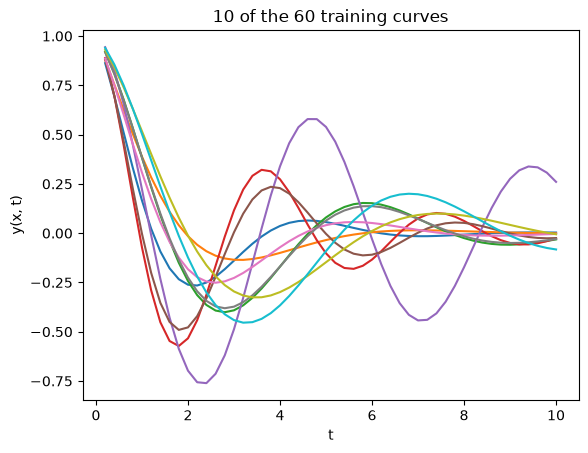

In [2]:
t = np.linspace(0.2, 10, 50)                      # q = 50 time steps

def simulator(X):
    f = 0.5 + X[:, [0]]
    a = 0.1 + 0.5 * X[:, [1]]
    return np.exp(-a * t) * np.cos(2 * np.pi * f * t / 5)   # n x q

rng = np.random.default_rng(1)
X = rng.uniform(size=(60, 2))
Y = simulator(X)
Xt = rng.uniform(size=(200, 2))
Yt = simulator(Xt)
print("X:", X.shape, " Y:", Y.shape)

plt.plot(t, Y[:10].T)
plt.xlabel("t"); plt.ylabel("y(x, t)"); plt.title("10 of the 60 training curves")
plt.show()

## 3. `"pca"` output model

`"pca(0.999)"` keeps the principal components that explain 99.9 % of the variance of the centered curves, and fits
one `Kriging` per component score. The truncation residual is kept as white noise, so the predicted standard
deviation does not ignore the discarded components.

In [3]:
t0 = time.time()
pca = lk.MultiOutputKriging(Y, X, "matern5_2", output_model="pca(0.999)")
t_pca = time.time() - t0
print(pca.summary())
print("components:", pca.nb_components(), " cumulative explained variance:", pca.pca_explained().round(4))

* MultiOutputKriging, output model: pca(0.999)
  * covariance kernel: matern5_2
  * data: 60 x 2 -> 60 x 50
  * trend: constant
  * PCA components: 7, explained variance: 0.999616
    - component 0: cum. explained 0.551869, sigma2 2.09793, theta    0.4896   1.1330
    - component 1: cum. explained 0.833887, sigma2 2.35078, theta    0.3952   0.8837
    - component 2: cum. explained 0.918672, sigma2 0.950284, theta    0.2956   0.7040
    - component 3: cum. explained 0.979497, sigma2 0.700393, theta    0.2813   0.7601
    - component 4: cum. explained 0.991474, sigma2 0.188176, theta    0.2374   0.6053
    - component 5: cum. explained 0.998876, sigma2 0.0584522, theta    0.2037   0.5488
    - component 6: cum. explained 0.999616, sigma2 0.00597473, theta    0.1393   0.4485

components: 7  cumulative explained variance: [0.5519 0.8339 0.9187 0.9795 0.9915 0.9989 0.9996]


In [4]:
def scores(mean, stdev):
    rmse = np.sqrt(np.mean((mean - Yt) ** 2))
    coverage = np.mean(np.abs(mean - Yt) <= 1.96 * stdev)
    return rmse / Yt.std(), coverage

mean, stdev, _, _ = pca.predict(Xt)
print("mean, stdev:", mean.shape, stdev.shape)
r_pca = scores(mean, stdev)
print(f"pca: RMSE / sd(Y) = {r_pca[0]:.4f}, coverage of the 95% intervals = {r_pca[1]:.3f}")

mean, stdev: (200, 50) (200, 50)
pca: RMSE / sd(Y) = 0.0791, coverage of the 95% intervals = 0.950


Predicted curves at three test inputs: predicted mean (solid), 95 % band (mean ± 1.96 stdev, shaded) and true
curve (dashed).

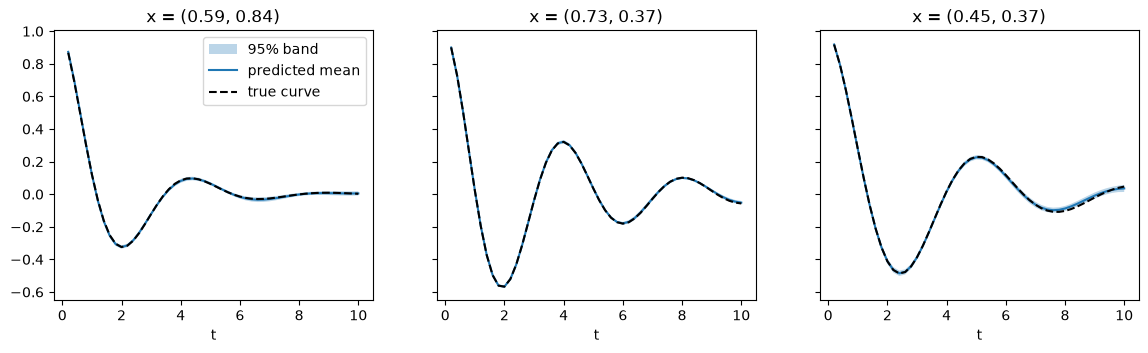

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for a, i in zip(ax, [0, 1, 2]):
    a.fill_between(t, mean[i] - 1.96 * stdev[i], mean[i] + 1.96 * stdev[i], alpha=0.3, label="95% band")
    a.plot(t, mean[i], label="predicted mean")
    a.plot(t, Yt[i], "k--", label="true curve")
    a.set_title(f"x = ({Xt[i, 0]:.2f}, {Xt[i, 1]:.2f})"); a.set_xlabel("t")
ax[0].legend(); plt.show()

## 4. `"shared"` output model

One θ for all 50 outputs, maximizing the summed concentrated log-likelihood: each likelihood evaluation costs
**one** Cholesky factorization for the 50 outputs. Each output keeps its own trend β_j and variance σ_j².

In [6]:
t0 = time.time()
shared = lk.MultiOutputKriging(Y, X, "matern5_2", output_model="shared")
t_shared = time.time() - t0
print("theta:", shared.theta())
mean_s, stdev_s, _, _ = shared.predict(Xt)
r_shared = scores(mean_s, stdev_s)
print(f"shared: RMSE / sd(Y) = {r_shared[0]:.4f}, coverage = {r_shared[1]:.3f}")

theta: [0.74818618 1.58683672]


shared: RMSE / sd(Y) = 0.0887, coverage = 0.968


## 5. Baseline: one independent `Kriging` per output

50 separate fits, each with its own θ. This remains a valid baseline: each time step gets the θ that suits it,
which can be slightly more accurate or not, depending on the design. The cost is 50 optimizations instead of one (`"shared"`) or a
handful (`"pca"`), no information shared between time steps, and no joint covariance between outputs.

In [7]:
t0 = time.time()
models = [lk.Kriging(Y[:, j], X, "matern5_2") for j in range(Y.shape[1])]
t_indep = time.time() - t0
mean_i = np.column_stack([k.predict(Xt, True, False, False)[0] for k in models])
stdev_i = np.column_stack([k.predict(Xt, True, False, False)[1] for k in models])
r_indep = scores(mean_i, stdev_i)
print(f"independent: RMSE / sd(Y) = {r_indep[0]:.4f}, coverage = {r_indep[1]:.3f}")

independent: RMSE / sd(Y) = 0.0647, coverage = 0.977


## 6. `"separable"` output model: joint covariance

`"separable"` estimates a free output covariance Σ (here between 3 close time steps, $t \approx 4.2, 4.6, 5.0$,
which are strongly correlated). Its predictive
covariance couples the outputs, $\mathrm{Cov}(\mathrm{vec}\,Y_n) = \Sigma \otimes C_x$, so it gives a consistent
uncertainty for any combination of outputs, e.g. the difference $Y(t_1) - Y(t_2)$. `"shared"` treats the outputs
as independent and gets that variance wrong when they are correlated.

`"separable"` needs $n - p \ge q$ and refuses nearly linearly dependent outputs (such as the 50 finely sampled time
steps): use `"pca"` or `"separable(<kernel>)"` for whole curves.

In [8]:
cols = [20, 22, 24]                                # t ~ 4.2, 4.6, 5.0
print("t:", t[cols].round(2))
sep = lk.MultiOutputKriging(Y[:, cols], X, "matern5_2", output_model="separable")
S = sep.output_cov()
sd = np.sqrt(np.diag(S))
print("output correlation:\n", (S / np.outer(sd, sd)).round(3))

t: [4.2 4.6 5. ]
output correlation:
 [[1.    0.882 0.575]
 [0.882 1.    0.887]
 [0.575 0.887 1.   ]]


Check on the test runs: compare the standard deviation of the standardized errors (error / predicted stdev) of
$Y(t_1)$ alone and of the difference $Y(t_1) - Y(t_2)$. Both models are conservative on $Y(t_1)$ alone (smooth
kernel), with a standard deviation below 1. `"separable"` stays of the same order for the difference;
`"shared"` ignores the correlation between the outputs, so its predicted variance of the difference is many times
too large and the standardized errors are much smaller than 1.

In [9]:
def calibration(model):
    # sd of the standardized errors of Y(t1) alone and of Y(t1) - Y(t2), from the joint covariance
    m, s, cov, _ = model.predict(Xt, return_cov=True)
    M = Xt.shape[0]
    var = np.array([cov[i, i] + cov[M + i, M + i] - 2 * cov[i, M + i] for i in range(M)])
    err1 = m[:, 0] - Yt[:, cols[0]]
    err = (m[:, 0] - m[:, 1]) - (Yt[:, cols[0]] - Yt[:, cols[1]])
    return np.std(err1 / s[:, 0]), np.std(err / np.sqrt(var))

sh3 = lk.MultiOutputKriging(Y[:, cols], X, "matern5_2", output_model="shared")
print("sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)")
for name, model in [("separable", sep), ("shared", sh3)]:
    c = calibration(model)
    print(f"  {name:10s}                     {c[0]:5.2f}   {c[1]:5.2f}")

Cx, Sigma = sep.predictCovFactors(Xt[:5])
print("predictCovFactors:", Cx.shape, Sigma.shape)

sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)
  separable                       0.77    0.57
  shared                          0.73    0.20
predictCovFactors: (5, 5) (3, 3)


## 7. `"separable(matern5_2)"`: a kernel over the time steps

With the time steps as output coordinates, Σ can be a kernel over them: $\Sigma = \sigma^2 R_t(\phi)$, here a
Matérn 5/2 correlation in $t$ with one range φ, estimated with θ by maximum likelihood. Two parameters replace the
$q(q+1)/2 = 1275$ entries of a free Σ, so the 50 finely sampled outputs are not a problem (the free Σ of
`"separable"` is singular there). The predictive mean is that of `"shared"` at the same θ; the joint covariance
couples all the time steps.

`normalize=true` gives each time step its own scale, which matters here since the curves decay along $t$.

In [10]:
t0 = time.time()
sk = lk.MultiOutputKriging(Y, X, "matern5_2", output_model="separable(matern5_2)", normalize=True,
                           output_coordinates=t)
t_sk = time.time() - t0
print("theta:", sk.theta().round(3), " phi (range in t):", sk.output_theta().round(3))
mean_k, stdev_k, _, _ = sk.predict(Xt)
r_sk = scores(mean_k, stdev_k)
print(f"separable(matern5_2): RMSE / sd(Y) = {r_sk[0]:.4f}, coverage = {r_sk[1]:.3f}")
S = sk.output_cov()
print("output correlation of t = 4.2 with t = 4.6, 5.0:", (S[20, [22, 24]] / S[20, 20]).round(3))

theta: [0.316 0.774]  phi (range in t): [1.295]
separable(matern5_2): RMSE / sd(Y) = 0.0684, coverage = 0.979
output correlation of t = 4.2 with t = 4.6, 5.0: [0.927 0.758]


Over all outputs, the standardized errors (error / predicted stdev) have a standard deviation somewhat below 1
(about 0.6 to 1 depending on the design): the model is a little conservative. Without `normalize=true` it is far
more so (about 0.07 on this design, coverage 1). The reason is that $R_t$ is **stationary**: one variance and one
correlation structure for the whole time axis, while these curves start from 1 for every input and decay along $t$.
Scaling each time step absorbs the decay; what remains is a correlation in $t$ that depends on $x$ (the frequency).
`"pca"` adapts to such curves without any assumption on $t$; `"separable(<kernel>)"` suits outputs whose
correlation depends mainly on the distance in $t$ (spatial fields, stationary time series), and gives a joint
covariance over all of them.

In [11]:
z = (mean_k - Yt) / stdev_k
print(f"sd of the standardized errors (all outputs): separable(matern5_2) {z.std():.2f}, "
      f"pca {((mean - Yt) / stdev).std():.2f}")

sd of the standardized errors (all outputs): separable(matern5_2) 0.59, pca 0.92


## 8. `update` and `update_simulate`

`simulate(..., will_update=true)` draws joint trajectories of all outputs and keeps what `update_simulate` needs.
When 5 new runs arrive, `update_simulate` conditions the **same** trajectories on them, without refitting. Its
empirical mean should match the prediction of the model updated with `update(..., refit=false)`.

simulate: (4, 50, 2000) (m x q x nsim)
max |empirical mean - updated mean| / max stdev: 0.0369


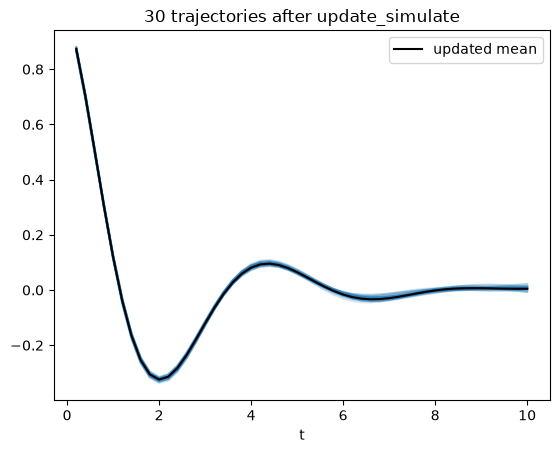

In [12]:
xs = Xt[:4]                                        # where the trajectories are drawn
Xu, Yu = Xt[100:105], Yt[100:105]                  # 5 new runs
sims = pca.simulate(nsim=2000, seed=7, X=xs, will_update=True)
print("simulate:", sims.shape, "(m x q x nsim)")
sims_u = pca.update_simulate(Yu, Xu)

pca.update(Yu, Xu, refit=False)
m_u, s_u, _, _ = pca.predict(xs)
print("max |empirical mean - updated mean| / max stdev:",
      round(np.abs(sims_u.mean(axis=2) - m_u).max() / s_u.max(), 4))

plt.plot(t, sims_u[0, :, :30], color="C0", alpha=0.2)
plt.plot(t, m_u[0], "k", label="updated mean")
plt.title("30 trajectories after update_simulate"); plt.xlabel("t"); plt.legend(); plt.show()

## 9. `save` and `load`

`save` writes the configuration, the data and the fitted state to a JSON file; `load` restores it exactly
(the generic `load` of each binding recognizes the file). The state of the last `simulate` is not saved: simulate
again before `update_simulate`.

In [13]:
import os, tempfile
f = os.path.join(tempfile.mkdtemp(), "pca.json")
pca.save(f)                                        # the updated pca model of section 8
loaded = lk.load(f)                                # or lk.MultiOutputKriging.load(f)
print("MultiOutputKriging:", isinstance(loaded, lk.MultiOutputKriging), "|", loaded.output_model(), "|", loaded.nb_components(), "components")
print("max |difference| of the predicted means:", np.abs(pca.predict(Xt)[0] - loaded.predict(Xt)[0]).max())

MultiOutputKriging: True | pca(0.999) | 7 components
max |difference| of the predicted means: 0.0


## 10. Summary

| Output model | Use it for | Hyperparameters |
|---|---|---|
| `"pca"` | many correlated outputs: curves, fields, q ≫ n possible | one Kriging per principal score |
| `"shared"` | outputs of similar regularity, marginal predictions | one θ, (β_j, σ_j²) per output |
| `"separable"` | a few correlated outputs, joint covariance or joint simulations | one θ, β_j per output, free Σ |
| `"separable(<kernel>)"` | outputs with coordinates and a stationary correlation along them, q ≫ n possible | one θ, β_j per output, σ², φ |

All four share the kernels, trends, `normalize` and optimizers of `Kriging`. Current limitations: isotopic design
only (no missing value in `Y`), no noise/nugget.

In [14]:
print(f"{'model':12s} {'RMSE/sd(Y)':>10s} {'coverage':>9s} {'fit time (s)':>13s}")
for name, r, tt in [("pca", r_pca, t_pca), ("shared", r_shared, t_shared), ("independent", r_indep, t_indep),
                    ("sep(matern)", r_sk, t_sk)]:
    print(f"{name:12s} {r[0]:10.4f} {r[1]:9.3f} {tt:13.2f}")

model        RMSE/sd(Y)  coverage  fit time (s)
pca              0.0791     0.950          0.04
shared           0.0887     0.968          0.01
independent      0.0647     0.977          0.22
sep(matern)      0.0684     0.979          0.02
